In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import list_raw_files, load_wca_tables, processed_data_dir
from src.preprocessing import (
    add_competition_dates,
    build_candidate_players,
    shortlist_candidate_players,
    build_player_trajectories,
)

EXPERIMENT_NAME = "case_study_333_10players"

# Data Exploration

Goal: which players and events are suitable for initially studying long-term skill acquisition.

Questions:

- What files exist?
- What columns exist?
- How many players?
- How many events?
- Which players have enough 333 data for time-series analysis?

In [2]:
tables = load_wca_tables(ROOT)
persons = tables["persons"]
competitions = add_competition_dates(tables["competitions"])
results = tables["results"]
events = tables["events"]

## Raw Files and Tables

In [4]:
raw_files = pd.DataFrame({"raw_file": list_raw_files(ROOT)})
display(raw_files)

file_overview = pd.DataFrame(
    [
        {"table": "persons", "rows": len(persons), "columns": persons.shape[1], "column_names": ", ".join(persons.columns)},
        {"table": "competitions", "rows": len(competitions), "columns": competitions.shape[1], "column_names": ", ".join(competitions.columns)},
        {"table": "results", "rows": len(results), "columns": results.shape[1], "column_names": ", ".join(results.columns)},
        {"table": "events", "rows": len(events), "columns": events.shape[1], "column_names": ", ".join(events.columns)},
    ]
)
display(file_overview)

print(f"Unique players (WCA IDs): {persons['wca_id'].nunique()}")
print(f"Unique events: {events['id'].nunique()}")

,raw_file
0,README.md
1,WCA_export_championships.tsv
2,WCA_export_competitions.tsv
3,WCA_export_continents.tsv
4,WCA_export_countries.tsv
5,WCA_export_eligible_country_iso2s_for_champion...
6,WCA_export_events.tsv
7,WCA_export_formats.tsv
8,WCA_export_persons.tsv
9,WCA_export_ranks_average.tsv


,table,rows,columns,column_names
0,persons,290235,5,"name, gender, wca_id, sub_id, country_id"
1,competitions,17799,23,"id, name, information, external_website, venue..."
2,results,6602196,13,"id, pos, best, average, competition_id, round_..."
3,events,21,4,"id, format, name, rank"


Unique players (WCA IDs): 289795
Unique events: 21


## Missing Values

In [5]:
missingness = pd.DataFrame({
    "persons": persons.isna().sum(),
    "competitions": competitions.isna().sum(),
    "results": results.isna().sum(),
}).fillna(0).astype(int)
display(missingness)

print(f"Unique players in results: {results['person_id'].nunique()}")
print(f"Competitions with dates: {competitions['date'].notna().sum()}")

,persons,competitions,results
average,0,0,0
best,0,0,0
cancelled,0,0,0
cell_name,0,0,0
city_name,0,0,0
competition_id,0,0,0
country_id,0,0,0
date,0,0,0
day,0,0,0
delegates,0,0,0


Unique players in results: 289795
Competitions with dates: 17799


## Event Focus: 333

In [3]:
event_catalog = events.loc[:, ["id", "name"]].sort_values("id").reset_index(drop=True)
display(event_catalog)

results_333 = results.loc[results["event_id"] == "333"].copy()
print(f"3x3x3 results rows: {len(results_333)}")
print(f"3x3x3 unique players: {results_333['person_id'].nunique()}")

,id,name
0,222,2x2x2 Cube
1,333,3x3x3 Cube
2,333bf,3x3x3 Blindfolded
3,333fm,3x3x3 Fewest Moves
4,333ft,3x3x3 With Feet
5,333mbf,3x3x3 Multi-Blind
6,333mbo,3x3x3 Multi-Blind Old Style
7,333oh,3x3x3 One-Handed
8,444,4x4x4 Cube
9,444bf,4x4x4 Blindfolded


3x3x3 results rows: 1788567
3x3x3 unique players: 278428


In [7]:
results_333.shape
results_333.head()

,id,pos,best,average,competition_id,round_type_id,event_id,person_name,person_id,format_id,regional_single_record,regional_average_record,person_country_id
0,14167,15,1968,2128,LyonOpen2007,1,333,Etienne Amany,2007AMAN01,a,AfR,AfR,Cote d_Ivoire
1,14168,16,1731,2140,LyonOpen2007,1,333,Thomas Rouault,2004ROUA01,a,NaN,NaN,France
2,14169,17,2305,2637,LyonOpen2007,1,333,Antoine Simon-Chautemps,2005SIMO01,a,NaN,NaN,France
3,14170,18,2452,2637,LyonOpen2007,1,333,Irène Mallordy,2007MALL01,a,NaN,NaN,France
4,14171,19,2677,2906,LyonOpen2007,1,333,Marlène Desmaisons,2007DESM01,a,NaN,NaN,France


## Competition Dates and Time Conversion

In [4]:
results_333_with_date = results_333.merge(
    competitions.loc[:, ["id", "date"]],
    left_on="competition_id",
    right_on="id",
    how="left",
)
results_333_with_date["best_sec"] = pd.to_numeric(results_333_with_date["best"], errors="coerce") / 100
results_333_with_date["average_sec"] = pd.to_numeric(results_333_with_date["average"], errors="coerce") / 100

display(results_333_with_date.loc[:, ["person_id", "person_name", "competition_id", "date", "best_sec", "average_sec"]].head())

,person_id,person_name,competition_id,date,best_sec,average_sec
0,2007AMAN01,Etienne Amany,LyonOpen2007,2007-09-01,19.68,21.28
1,2004ROUA01,Thomas Rouault,LyonOpen2007,2007-09-01,17.31,21.40
2,2005SIMO01,Antoine Simon-Chautemps,LyonOpen2007,2007-09-01,23.05,26.37
3,2007MALL01,Irène Mallordy,LyonOpen2007,2007-09-01,24.52,26.37
4,2007DESM01,Marlène Desmaisons,LyonOpen2007,2007-09-01,26.77,29.06


## Candidate Player Table

In [5]:
candidate_players = build_candidate_players(
    results=results,
    competitions=competitions,
    event_id="333",
    min_results=50,
)

candidate_players_table = candidate_players.rename(columns={
    "person_id": "WCA ID",
    "person_name": "Name",
    "n_competitions": "#Competitions",
    "n_results": "#Results",
    "first_year": "First Year",
    "last_year": "Last Year",
})[[
    "WCA ID",
    "Name",
    "#Competitions",
    "#Results",
    "First Year",
    "Last Year",
    "span",
]].rename(columns={"span": "Span"})

display(candidate_players_table.head(20))

,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2017GARR05,Luke Garrett,267,794,2017,2026,9
2,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
3,2009PROV01,Matteo Provasi,281,750,2009,2026,17
4,2013WALL03,Daniel Wallin,296,711,2013,2026,13
5,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
6,2009LIUE01,Evan Liu,264,700,2009,2026,17
7,2010HULL01,Katie Hull,236,684,2010,2026,16
8,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
9,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13


## Save Candidate Table

In [ ]:
#experiment_name = "case_study_333_10players"
processed_dir = processed_data_dir(ROOT, experiment_name=EXPERIMENT_NAME)
processed_dir.mkdir(parents=True, exist_ok=True)
candidate_path = processed_dir / "candidate_players.csv"
candidate_players_table.to_csv(candidate_path, index=False)

print(f"Saved candidate table to: {candidate_path}")
print(f"Candidate rows: {len(candidate_players_table)}")

Saved candidate table to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\processed\candidate_players.csv
Candidate rows: 5908


## Shortlist 5-10 Players

Selection rule:

- Primary rule: `Results >= 200` and `Span >= 10` years.
- Fallback if fewer than 5 players: `Results >= 100` and `Span >= 5` years.
- Final fallback: `Results >= 50` and `Span >= 3` years.
- Keep the top 10 by `Results`, `Span`, and `#Competitions`.


In [ ]:
# Rule-based player selection with fallbacks.
selection_rule = {
    "primary": {"min_results": 200, "min_span": 10},
    "fallback_1": {"min_results": 100, "min_span": 5},
    "fallback_2": {"min_results": 50, "min_span": 3},
    "n_players": 10,
    "min_keep": 5,
}

for rule_name in ["primary", "fallback_1", "fallback_2"]:
    rule = selection_rule[rule_name]
    pool = candidate_players.loc[
        (candidate_players["n_results"] >= rule["min_results"])
        & (candidate_players["span"] >= rule["min_span"])
    ].copy()
    if len(pool) >= selection_rule["min_keep"] or rule_name == "fallback_2":
        active_rule_name = rule_name
        active_rule = rule
        break

# Selected the ten players with the highest number of recorded results among 
# competitors having at least X results and Y years of activity
# selected_players = (
#     pool.sort_values(["n_results", "span", "n_competitions"], ascending=[False, False, False])
#     .head(selection_rule["n_players"])
#     .reset_index(drop=True)
# )
selected_players = shortlist_candidate_players(
    candidate_players,
    n_candidates=10,
    min_results=200,
    fallback_min_results=50,
    min_span=3,
)

selected_players_table = selected_players.rename(columns={
    "person_id": "WCA ID",
    "person_name": "Name",
    "n_competitions": "#Competitions",
    "n_results": "#Results",
    "first_year": "First Year",
    "last_year": "Last Year",
})[[
    "WCA ID",
    "Name",
    "#Competitions",
    "#Results",
    "First Year",
    "Last Year",
    "span",
]].rename(columns={"span": "Span"})

print(f"Active rule: {active_rule_name} (min_results={active_rule['min_results']}, min_span={active_rule['min_span']})")
print(f"Selected players: {len(selected_players_table)}")
display(selected_players_table)

Active rule: primary (min_results=200, min_span=10)
Selected players: 10


,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
2,2009PROV01,Matteo Provasi,281,750,2009,2026,17
3,2013WALL03,Daniel Wallin,296,711,2013,2026,13
4,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
5,2009LIUE01,Evan Liu,264,700,2009,2026,17
6,2010HULL01,Katie Hull,236,684,2010,2026,16
7,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
8,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13
9,2012PARK03,Max Park,203,618,2012,2026,14


## Candidate Ranking Preview

In [15]:
ranked_candidates = candidate_players_table.sort_values(["#Results", "Span"], ascending=[False, False])
display(ranked_candidates.head(10))

,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2017GARR05,Luke Garrett,267,794,2017,2026,9
2,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
3,2009PROV01,Matteo Provasi,281,750,2009,2026,17
4,2013WALL03,Daniel Wallin,296,711,2013,2026,13
5,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
6,2009LIUE01,Evan Liu,264,700,2009,2026,17
7,2010HULL01,Katie Hull,236,684,2010,2026,16
8,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
9,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13


In [16]:
print(f"Candidate pool size (min 50 results): {len(candidate_players_table)}")
print(f"Selected shortlist size: {len(selected_players_table)}")
display(selected_players_table)

Candidate pool size (min 50 results): 5908
Selected shortlist size: 10


,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2017GARR05,Luke Garrett,267,794,2017,2026,9
2,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
3,2009PROV01,Matteo Provasi,281,750,2009,2026,17
4,2013WALL03,Daniel Wallin,296,711,2013,2026,13
5,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
6,2009LIUE01,Evan Liu,264,700,2009,2026,17
7,2010HULL01,Katie Hull,236,684,2010,2026,16
8,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
9,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13


## Validation

In [17]:
saved_candidate_players = pd.read_csv(candidate_path)
display(saved_candidate_players.head(10))

print(f"Saved rows: {len(saved_candidate_players)}")
print(f"Selected players: {len(selected_players_table)}")

,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2017GARR05,Luke Garrett,267,794,2017,2026,9
2,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
3,2009PROV01,Matteo Provasi,281,750,2009,2026,17
4,2013WALL03,Daniel Wallin,296,711,2013,2026,13
5,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
6,2009LIUE01,Evan Liu,264,700,2009,2026,17
7,2010HULL01,Katie Hull,236,684,2010,2026,16
8,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
9,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13


Saved rows: 5908
Selected players: 10


In [ ]:
project_structure = pd.DataFrame(
    [
        {"notebook": "01_data_exploration.ipynb", "purpose": "file inventory, candidate selection, and one-player exploratory plots"},
        {"notebook": "02_learning_models.ipynb", "purpose": "trajectories, power law, exponential, and model comparison"},
        {"notebook": "03_dfa_analysis.ipynb", "purpose": "DFA, Hurst exponent, and persistence"},
        {"notebook": "04_distribution_analysis.ipynb", "purpose": "early vs. late phase variability reduction"},
        {"notebook": "05_results_summary.ipynb", "purpose": "final figures and tables for the single 333 experiment"},
        {"notebook": "06_cross_experiment_summary.ipynb", "purpose": "robustness check across multiple events and sample sizes"},
    ]
)
display(project_structure)

,notebook,purpose
0,01_data_exploration.ipynb,"file inventory, columns, counts, candidate sel..."
1,03_learning_curves.ipynb,date vs solve time plots
2,04_model_fitting.ipynb,power law and exponential fits
3,05_residual_analysis.ipynb,"residuals, DFA, and Hurst exponent"
4,06_distribution_analysis.ipynb,"Gaussian, log-normal, and Ex-Gaussian comparisons"


## One Player Plots

In [ ]:
# One example player for exploratory plots.
# First selected player. 
# Set a WCA ID in `manual_player_id` to override.
manual_player_id = None
example_player_id = manual_player_id or selected_players_table.iloc[0]["WCA ID"]

player = results_333_with_date.loc[
    results_333_with_date["person_id"] == example_player_id,
    [
        "person_id",
        "person_name",
        "competition_id",
        "date",
        "best",
        "average",
        "best_sec",
        "average_sec",
    ],
].copy()

if player.empty:
    raise ValueError(f"No 333 data found for player ID: {example_player_id}")

player_name = player["person_name"].iloc[0]

print(f"Example player: {player_name} ({example_player_id})")
print(f"Rows: {len(player)}")
print(f"Competitions: {player['competition_id'].nunique()}")
print(f"First date: {player['date'].min().date()}")
print(f"Last date: {player['date'].max().date()}")

Example player: Eduard Esteban García Domínguez (2011EDUA01)
Rows: 860
Competitions: 324
First date: 2011-10-02
Last date: 2026-05-24


In [6]:
# Sort by date and keep only valid rows.
player = player.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
player["solve_index"] = range(1, len(player) + 1)

display(player.head())
print(f"Valid dated rows: {len(player)}")

,person_id,person_name,competition_id,date,best,average,best_sec,average_sec,solve_index
0,2012PARK03,Max Park,NiseiWeek2012,2012-08-18,1784,2056,17.84,20.56,1
1,2012PARK03,Max Park,DiamondBar2012,2012-10-14,1488,1660,14.88,16.60,2
2,2012PARK03,Max Park,DiamondBar2012,2012-10-14,1594,1901,15.94,19.01,3
3,2012PARK03,Max Park,CaltechSpring2013,2013-05-25,1350,1513,13.50,15.13,4
4,2012PARK03,Max Park,SanDiegoSummer2013,2013-06-08,1255,1396,12.55,13.96,5


Valid dated rows: 618


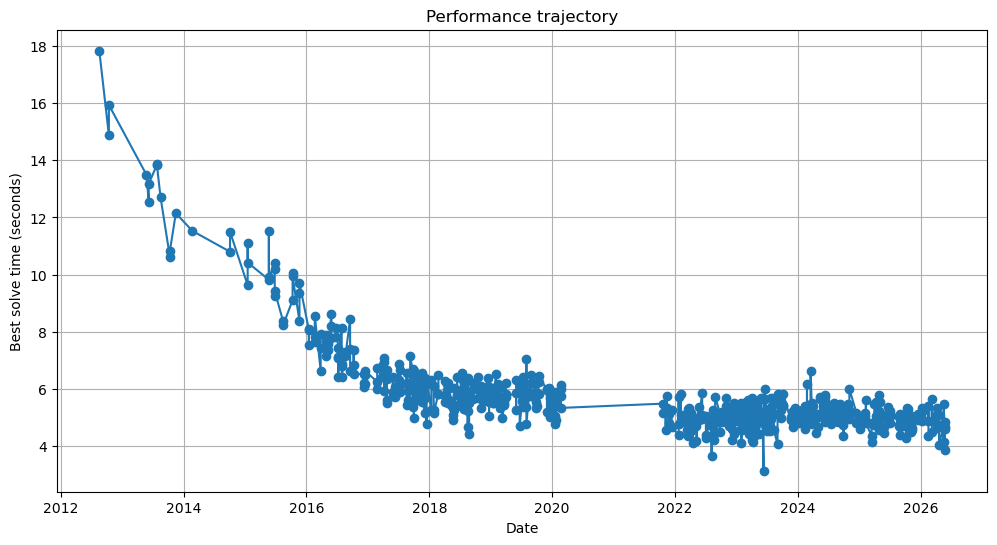

In [7]:
# Learning trajectory

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    player["date"],
    player["best"]/100,
    marker="o",
    linestyle="-"
)

plt.ylabel("Best solve time (seconds)")
plt.xlabel("Date")
plt.title("Performance trajectory")
plt.grid(True)

plt.show()

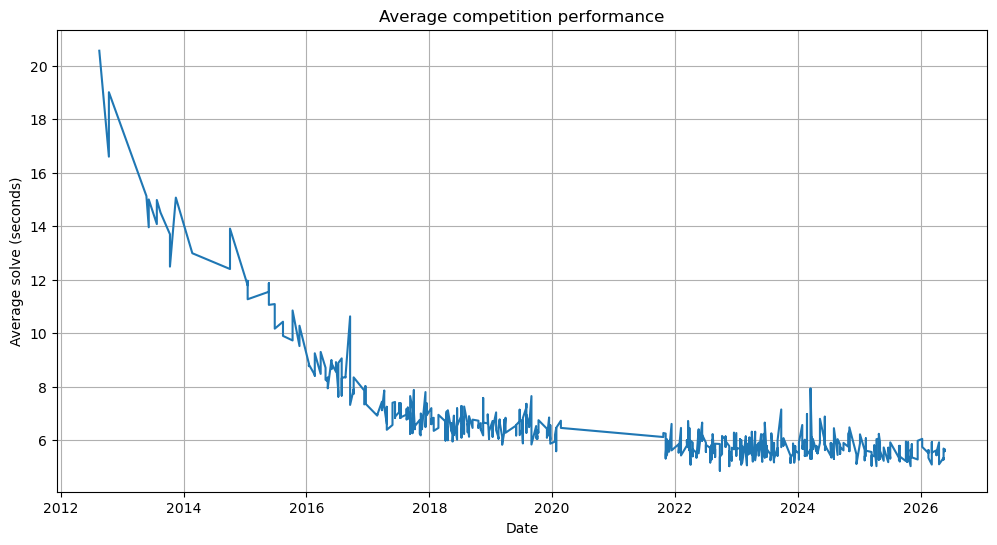

In [8]:
# average result

valid = player[player["average"] > 0]

plt.figure(figsize=(12,6))

plt.plot(
    valid["date"],
    valid["average"]/100
)

plt.ylabel("Average solve (seconds)")
plt.xlabel("Date")
plt.title("Average competition performance")

plt.grid(True)

plt.show()

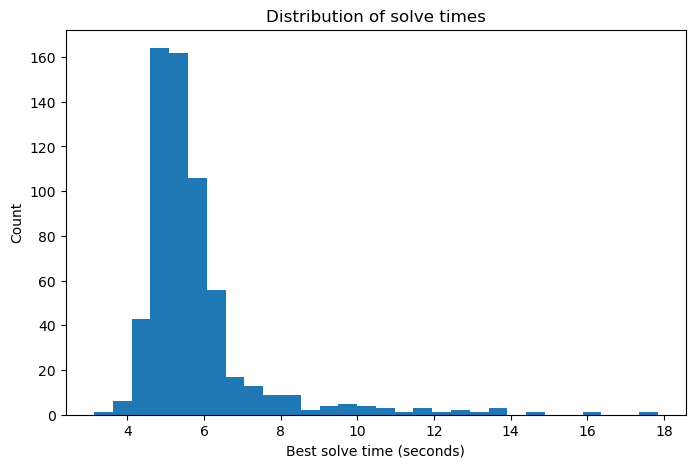

In [9]:
# historgram

plt.figure(figsize=(8,5))

plt.hist(
    player["best"]/100,
    bins=30
)

plt.xlabel("Best solve time (seconds)")
plt.ylabel("Count")

plt.title("Distribution of solve times")

plt.show()

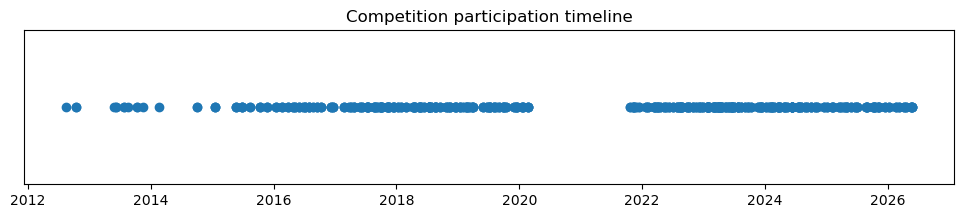

In [10]:
# career timeline

plt.figure(figsize=(12,2))

plt.scatter(
    player["date"],
    [1]*len(player)
)

plt.yticks([])

plt.title("Competition participation timeline")

plt.show()

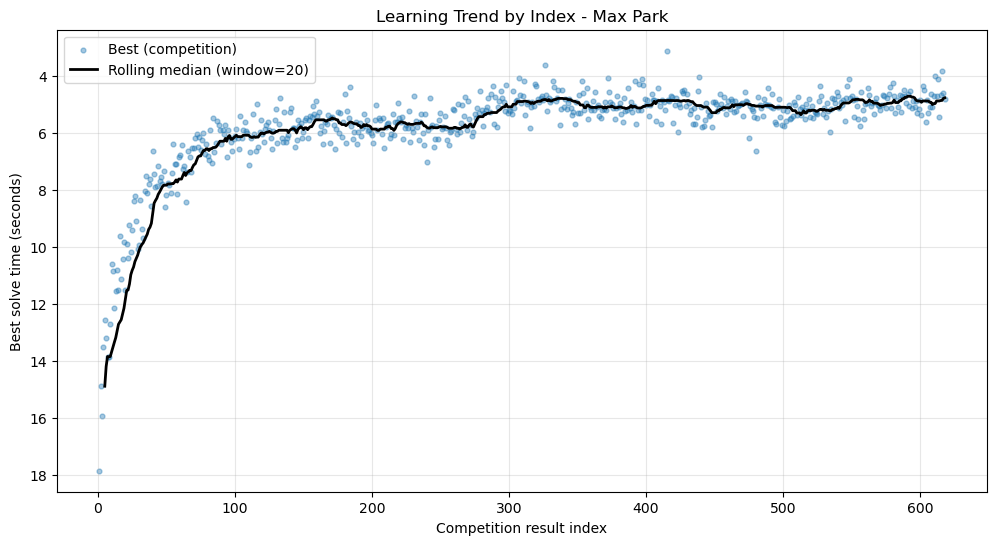

In [ ]:
# Trend over attempt index 
import matplotlib.pyplot as plt

valid_best = player[player["best_sec"] > 0].copy()
valid_best["rolling_best_sec"] = valid_best["best_sec"].rolling(window=20, min_periods=5).median()

plt.figure(figsize=(12, 6))
plt.scatter(valid_best["solve_index"], valid_best["best_sec"], s=12, alpha=0.4, label="Best (competition)")
plt.plot(valid_best["solve_index"], valid_best["rolling_best_sec"], color="black", linewidth=2, label="Rolling median (window=20)")
plt.gca().invert_yaxis()
plt.xlabel("Competition result index")
plt.ylabel("Best solve time (seconds)")
plt.title(f"Learning Trend by Index - {player_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,year,competitions,n_results,median_best_sec,median_average_sec
0,2012,2,3,15.940,19.010
1,2013,6,9,12.710,14.510
2,2014,2,3,11.500,12.990
3,2015,6,18,9.760,10.710
4,2016,14,42,7.375,8.340
5,2017,19,60,6.055,6.935
6,2018,22,69,5.750,6.600
7,2019,20,61,5.790,6.430
8,2020,3,10,5.460,6.455
9,2021,5,12,5.210,5.860


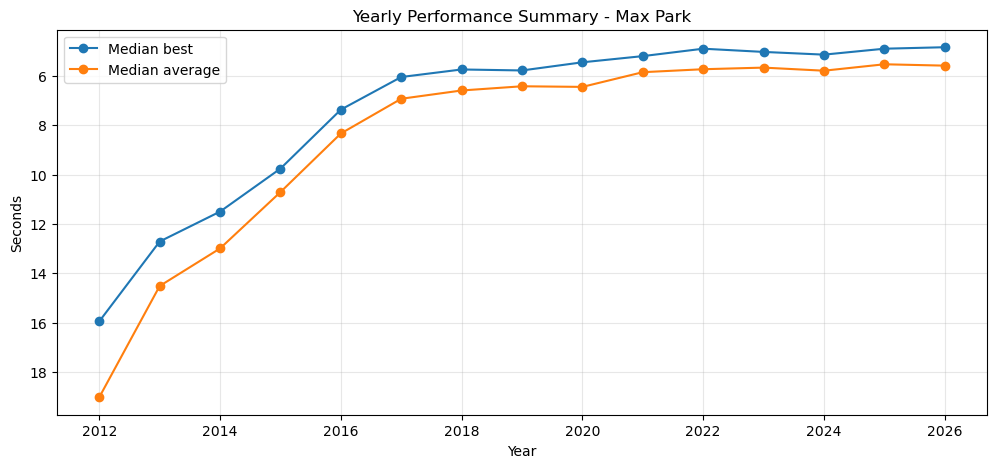

In [ ]:
# Yearly summary
yearly = (
    player.assign(year=player["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        competitions=("competition_id", "nunique"),
        n_results=("competition_id", "size"),
        median_best_sec=("best_sec", "median"),
        median_average_sec=("average_sec", "median"),
    )
)

display(yearly)

plt.figure(figsize=(12, 5))
plt.plot(yearly["year"], yearly["median_best_sec"], marker="o", label="Median best")
plt.plot(yearly["year"], yearly["median_average_sec"], marker="o", label="Median average")
plt.gca().invert_yaxis()
plt.xlabel("Year")
plt.ylabel("Seconds")
plt.title(f"Yearly Performance Summary - {player_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Save selected players and their trajectories

In [ ]:
# Save selected players and trajectories to processed data
selected_path = processed_dir / "selected_players.csv"
selected_players_table.to_csv(selected_path, index=False)

player_trajectories = build_player_trajectories(
    results_with_dates=results_333_with_date,
    selected_players=selected_players_table,
    selected_id_column="WCA ID",
    results_id_column="person_id",
    date_column="date",
    average_column="average_sec",
)

trajectories_path = processed_dir / "player_trajectories.csv"
player_trajectories.to_csv(trajectories_path, index=False)

print(f"Saved selected players to: {selected_path}")
print(f"Saved player trajectories to: {trajectories_path}")
print(f"Trajectory rows: {len(player_trajectories)}")

Saved selected players to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\processed\selected_players.csv
Saved player trajectories to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\processed\player_trajectories.csv
Trajectory rows: 7056


In [ ]:
# Quick validation of all processed outputs
saved_candidate_players = pd.read_csv(candidate_path)
saved_selected_players = pd.read_csv(selected_path)
saved_player_trajectories = pd.read_csv(trajectories_path, parse_dates=["competition_date"])

print(f"candidate_players.csv rows: {len(saved_candidate_players)}")
print(f"selected_players.csv rows: {len(saved_selected_players)}")
print(f"player_trajectories.csv rows: {len(saved_player_trajectories)}")
print(f"player_trajectories.csv columns: {list(saved_player_trajectories.columns)}")

display(saved_selected_players.head(10))
display(saved_player_trajectories.head(10))

candidate_players.csv rows: 5908
selected_players.csv rows: 10
player_trajectories.csv rows: 7056
player_trajectories.csv columns: ['person_id', 'person_name', 'competition_date', 'average_seconds', 'seq_index']


,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
2,2009PROV01,Matteo Provasi,281,750,2009,2026,17
3,2013WALL03,Daniel Wallin,296,711,2013,2026,13
4,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
5,2009LIUE01,Evan Liu,264,700,2009,2026,17
6,2010HULL01,Katie Hull,236,684,2010,2026,16
7,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
8,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13
9,2012PARK03,Max Park,203,618,2012,2026,14


,person_id,person_name,competition_date,average_seconds,seq_index
0,2009LIUE01,Evan Liu,2009-05-30,44.77,1
1,2009LIUE01,Evan Liu,2009-08-14,33.30,2
2,2009LIUE01,Evan Liu,2010-01-30,20.28,3
3,2009LIUE01,Evan Liu,2010-01-30,21.71,4
4,2009LIUE01,Evan Liu,2010-04-18,20.91,5
5,2009LIUE01,Evan Liu,2010-06-13,21.23,6
6,2009LIUE01,Evan Liu,2010-06-13,18.13,7
7,2009LIUE01,Evan Liu,2010-06-13,21.16,8
8,2009LIUE01,Evan Liu,2010-08-06,20.03,9
9,2009LIUE01,Evan Liu,2010-10-16,17.15,10


In [6]:
# Coverage per selected player
coverage = (
    player_trajectories.groupby(["person_id", "person_name"], as_index=False)
    .agg(
        n_points=("competition_date", "size"),
        first_date=("competition_date", "min"),
        last_date=("competition_date", "max"),
        max_seq_index=("seq_index", "max"),
    )
)
coverage["span_years"] = (
    pd.to_datetime(coverage["last_date"]).dt.year - pd.to_datetime(coverage["first_date"]).dt.year
)
coverage = coverage.sort_values(["n_points", "span_years"], ascending=[False, False]).reset_index(drop=True)

display(coverage)

,person_id,person_name,n_points,first_date,last_date,max_seq_index,span_years
0,2011EDUA01,Eduard Esteban García Domínguez,860,2011-10-02,2026-05-24,860,15
1,2010ROSE03,Dennis Rosero,759,2010-12-11,2026-05-24,759,16
2,2009PROV01,Matteo Provasi,750,2009-12-07,2026-05-23,750,17
3,2013WALL03,Daniel Wallin,711,2013-09-14,2026-05-25,711,13
4,2012MAHV01,Paul Mahvi,701,2012-09-02,2026-05-23,701,14
5,2009LIUE01,Evan Liu,700,2009-05-30,2026-05-17,700,17
6,2010HULL01,Katie Hull,684,2010-07-31,2026-05-24,684,16
7,2014ZAKR01,Karol Zakrzewski,648,2014-02-22,2026-05-23,648,12
8,2013ROGA02,Przemysław Rogalski,626,2013-12-14,2026-05-23,626,13
9,2012PARK03,Max Park,617,2012-08-18,2026-05-23,617,14
